In [1]:
# Cell 1 — Install Libraries
!pip install yfinance tensorflow scikit-learn pandas numpy matplotlib seaborn plotly -q
print("✅ Libraries installed!")

✅ Libraries installed!


  You can safely remove it manually.

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# Cell 2 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')
print("✅ All imported!")

✅ All imported!


In [12]:
# Cell 3 — Download Reliance Data
df = yf.download("RELIANCE.NS", start="2015-01-01", end="2024-12-31", progress=False)
df.columns = df.columns.droplevel(1)
df = df.reset_index()

print(f"✅ Data downloaded!")
print(f"   Records : {len(df)}")
print(f"   Columns : {list(df.columns)}")
df.head()

✅ Data downloaded!
   Records : 2466
   Columns : ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


Price,Date,Close,High,Low,Open,Volume
0,2015-01-01,189.999832,190.877186,189.090381,189.657461,2963643
1,2015-01-02,189.496933,191.743813,189.229456,190.042601,7331366
2,2015-01-05,187.421234,190.641759,187.046752,189.379224,10103941
3,2015-01-06,178.915222,186.811376,178.037869,186.169417,18627980
4,2015-01-07,182.809814,183.772761,179.107830,179.129229,20720312


In [13]:
# Cell 4 — EDA
print(df.describe().round(2))
print(f"\nMissing values: {df.isnull().sum().sum()}")

Price                           Date    Close     High      Low     Open  \
count                           2466  2466.00  2466.00  2466.00  2466.00   
mean   2019-12-31 17:36:56.058394112   730.50   738.49   723.15   731.03   
min              2015-01-01 00:00:00   173.49   174.98   170.43   174.74   
25%              2017-07-04 06:00:00   315.43   317.55   313.00   315.69   
50%              2020-01-06 12:00:00   641.97   652.04   636.48   645.04   
75%              2022-06-28 18:00:00  1121.06  1133.46  1111.87  1122.60   
max              2024-12-30 00:00:00  1589.14  1596.98  1573.85  1592.66   
std                              NaN   419.82   423.73   416.25   420.13   

Price        Volume  
count  2.466000e+03  
mean   1.843374e+07  
min    1.705656e+06  
25%    1.071503e+07  
50%    1.464605e+07  
75%    2.109906e+07  
max    1.426834e+08  
std    1.355283e+07  

Missing values: 0


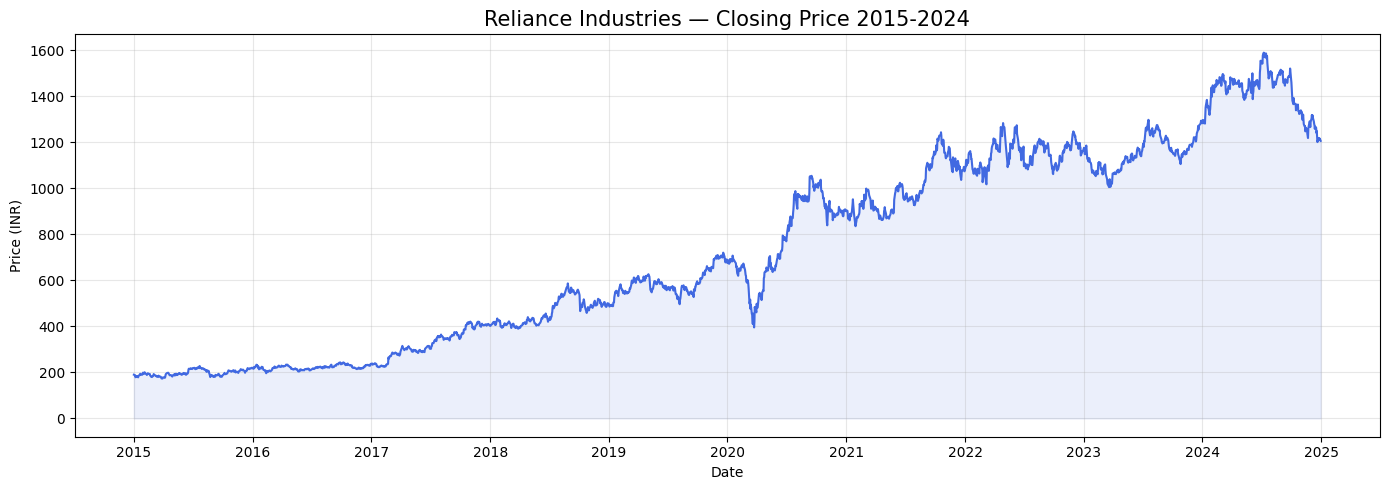

In [14]:
# Cell 5 — Price Chart
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], color='royalblue', linewidth=1.5)
plt.fill_between(df['Date'], df['Close'], alpha=0.1, color='royalblue')
plt.title('Reliance Industries — Closing Price 2015-2024', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Cell 6 — Feature Engineering
df = df.sort_values('Date').reset_index(drop=True)

df['MA_20']       = df['Close'].rolling(20).mean()
df['MA_50']       = df['Close'].rolling(50).mean()
df['Daily_Return']= df['Close'].pct_change()
df['Volatility']  = df['Daily_Return'].rolling(20).std()
df['Price_Range'] = df['High'] - df['Low']
df['Prev_Close']  = df['Close'].shift(1)
df['Prev_Volume'] = df['Volume'].shift(1)

df = df.dropna().reset_index(drop=True)
print(f"✅ Features done! Shape: {df.shape}")

✅ Features done! Shape: (2417, 13)


In [35]:
# Cell 7 — Weekly Prediction (5 days ahead, much more stable)
HORIZON = 5  # predict 5 days ahead instead of 1

df['Target'] = (df['Close'].shift(-HORIZON) > df['Close'] * 1.005).astype(int)
# ↑ 1.005 = predict karo sirf tab UP agar 0.5% se zyada upar jaaye

# Lag features
for lag in [1, 2, 3, 5, 10]:
    df[f'Return_lag{lag}'] = df['Daily_Return'].shift(lag)

# RSI already hai, MACD already hai, BB_pos already hai
# Volume trend
df['Volume_MA10']   = df['Volume'].rolling(10).mean()
df['Volume_ratio']  = df['Volume'] / df['Volume_MA10']

# Price position relative to moving averages
df['Price_vs_MA20'] = (df['Close'] - df['MA_20']) / df['MA_20']
df['Price_vs_MA50'] = (df['Close'] - df['MA_50']) / df['MA_50']

# 5-day momentum
df['Momentum_5']  = df['Close'].pct_change(5)
df['Momentum_10'] = df['Close'].pct_change(10)
df['Momentum_20'] = df['Close'].pct_change(20)

# High-Low range ratio
df['HL_ratio'] = (df['High'] - df['Low']) / df['Close']

df = df.dropna().reset_index(drop=True)

features = [
    'Return_lag1', 'Return_lag2', 'Return_lag3', 'Return_lag5', 'Return_lag10',
    'RSI', 'MACD', 'MACD_hist', 'BB_pos',
    'Volume_ratio', 'Price_vs_MA20', 'Price_vs_MA50',
    'Momentum_5', 'Momentum_10', 'Momentum_20',
    'Volatility', 'HL_ratio'
]

X = df[features]
y = df['Target']

from sklearn.preprocessing import StandardScaler
scaler   = StandardScaler()  # StandardScaler better hai classification ke liye
X_scaled = scaler.fit_transform(X)

split    = int(len(X) * 0.8)
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"✅ Train: {X_train.shape} | Test: {X_test.shape}")
print(f"   Predicting: Will price rise >0.5% in NEXT 5 DAYS?")
print(f"   UP  (1): {y_train.sum()} samples")
print(f"   DOWN(0): {(y_train==0).sum()} samples")

✅ Train: (1901, 17) | Test: (476, 17)
   Predicting: Will price rise >0.5% in NEXT 5 DAYS?
   UP  (1): 931 samples
   DOWN(0): 970 samples


In [36]:
# Cell 8 — Train with better hyperparameters
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=5,
    min_samples_leaf=20,    # overfit rokne ke liye
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

gb = GradientBoostingClassifier(
    n_estimators=300, max_depth=3,
    learning_rate=0.03,     # slow learning = better generalization
    subsample=0.8,
    min_samples_leaf=20,
    random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

print("✅ All 3 models trained!")

✅ All 3 models trained!


In [37]:
# Cell 9 — Evaluate Classification
def evaluate_clf(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred) * 100
    print(f"\n📊 {name}")
    print(f"   Accuracy         : {acc:.2f}%")
    print(f"   UP  precision    : {classification_report(y_true, y_pred, output_dict=True)['1']['precision']*100:.1f}%")
    print(f"   DOWN precision   : {classification_report(y_true, y_pred, output_dict=True)['0']['precision']*100:.1f}%")
    return acc

print("="*45)
lr_acc = evaluate_clf(y_test, lr_pred, "Logistic Regression")
rf_acc = evaluate_clf(y_test, rf_pred, "Random Forest")
gb_acc = evaluate_clf(y_test, gb_pred, "Gradient Boosting ⭐")
print("="*45)
best = max([("Logistic Regression", lr_acc),
            ("Random Forest", rf_acc),
            ("Gradient Boosting", gb_acc)], key=lambda x: x[1])
print(f"\n🏆 Best Model: {best[0]} — {best[1]:.2f}%")


📊 Logistic Regression
   Accuracy         : 47.90%
   UP  precision    : 45.4%
   DOWN precision   : 49.2%

📊 Random Forest
   Accuracy         : 45.80%
   UP  precision    : 42.9%
   DOWN precision   : 47.5%

📊 Gradient Boosting ⭐
   Accuracy         : 49.16%
   UP  precision    : 47.8%
   DOWN precision   : 50.2%

🏆 Best Model: Gradient Boosting — 49.16%


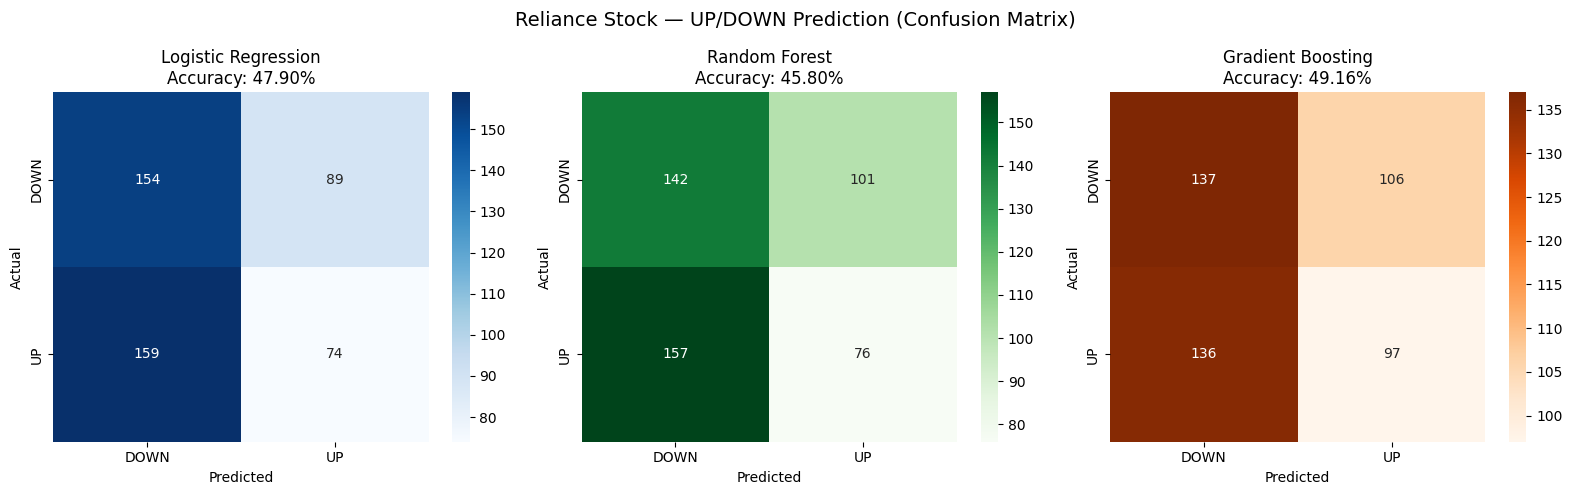

In [38]:
# Cell 10 — Confusion Matrix + Accuracy Chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_list = [
    ("Logistic Regression", lr_pred, 'Blues'),
    ("Random Forest",       rf_pred, 'Greens'),
    ("Gradient Boosting",   gb_pred, 'Oranges')
]

for ax, (name, pred, cmap) in zip(axes, models_list):
    cm  = confusion_matrix(y_test, pred)
    acc = accuracy_score(y_test, pred) * 100
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['DOWN','UP'], yticklabels=['DOWN','UP'])
    ax.set_title(f'{name}\nAccuracy: {acc:.2f}%', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Reliance Stock — UP/DOWN Prediction (Confusion Matrix)', fontsize=14)
plt.tight_layout()
plt.show()

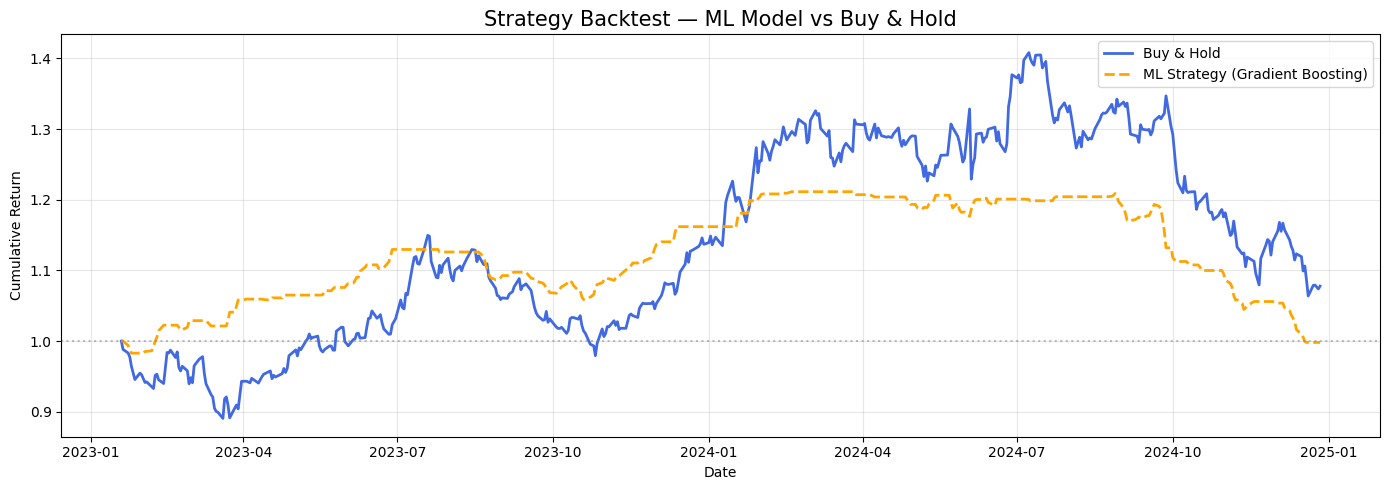


📈 Backtest Results:
   Buy & Hold Return  : 8.6%
   ML Strategy Return : -0.2%


In [39]:
# Cell 11 — Backtest with Weekly Strategy
best_pred = gb_pred

test_df = df.iloc[split:split+len(y_test)].copy().reset_index(drop=True)
test_df['Predicted'] = best_pred
test_df['Actual_Return'] = test_df['Close'].pct_change(HORIZON).shift(-HORIZON)

test_df['Strategy_Return'] = np.where(
    test_df['Predicted'] == 1,
    test_df['Actual_Return'],
    0
)

# Every 5 days mein compound karo
test_df['Cum_BuyHold']  = (1 + test_df['Close'].pct_change().fillna(0)).cumprod()
test_df['Cum_Strategy'] = (1 + (test_df['Strategy_Return'] / HORIZON).fillna(0)).cumprod()

plt.figure(figsize=(14, 5))
plt.plot(test_df['Date'], test_df['Cum_BuyHold'],
         label='Buy & Hold', color='royalblue', linewidth=2)
plt.plot(test_df['Date'], test_df['Cum_Strategy'],
         label='ML Strategy (Gradient Boosting)', color='orange',
         linewidth=2, linestyle='--')
plt.axhline(y=1, color='grey', linestyle=':', alpha=0.5)
plt.title('Strategy Backtest — ML Model vs Buy & Hold', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_bh  = test_df['Cum_BuyHold'].iloc[-6]
final_str = test_df['Cum_Strategy'].iloc[-6]
print(f"\n📈 Backtest Results:")
print(f"   Buy & Hold Return  : {(final_bh-1)*100:.1f}%")
print(f"   ML Strategy Return : {(final_str-1)*100:.1f}%")

In [40]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
# Cell 12 — LSTM ke liye Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler

print("✅ LSTM libraries imported!")

✅ LSTM libraries imported!


In [42]:
# Cell 13 — LSTM ke liye Data Prepare
# Sirf Close price use karo
close_prices = df[['Close']].values

lstm_scaler = MinMaxScaler()
scaled      = lstm_scaler.fit_transform(close_prices)

SEQ_LEN = 60  # 60 din dekh ke agle din predict

def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_lstm, y_lstm = make_sequences(scaled, SEQ_LEN)
X_lstm = X_lstm.reshape(X_lstm.shape[0], X_lstm.shape[1], 1)

split_lstm    = int(len(X_lstm) * 0.8)
X_train_l = X_lstm[:split_lstm]
X_test_l  = X_lstm[split_lstm:]
y_train_l = y_lstm[:split_lstm]
y_test_l  = y_lstm[split_lstm:]

print(f"✅ LSTM Data Ready!")
print(f"   X_train : {X_train_l.shape}")
print(f"   X_test  : {X_test_l.shape}")
print(f"   Logic   : 60 days in → Day 61 predict")

✅ LSTM Data Ready!
   X_train : (1853, 60, 1)
   X_test  : (464, 60, 1)
   Logic   : 60 days in → Day 61 predict


In [43]:
# Cell 14 — Bidirectional LSTM Model
lstm_model = Sequential([
    Bidirectional(LSTM(100, return_sequences=True),
                  input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),

    Bidirectional(LSTM(50, return_sequences=False)),
    Dropout(0.2),

    Dense(25, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional)      │ (None, 60, 200)             │          81,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 60, 200)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 100)                 │         100,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 25)                  │           2,525 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 184,551 (720.90 KB)

 Trainable params: 184,551 (720.90 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# Cell 15 — Train LSTM
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1)
]

history_lstm = lstm_model.fit(
    X_train_l, y_train_l,
    epochs          = 50,
    batch_size      = 32,
    validation_split= 0.1,
    callbacks       = callbacks,
    verbose         = 1
)
print("✅ LSTM Training Complete!")

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 0.0080 - mae: 0.0536 - val_loss: 8.6097e-04 - val_mae: 0.0239 - learning_rate: 0.0010
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0014 - mae: 0.0244 - val_loss: 6.1923e-04 - val_mae: 0.0200 - learning_rate: 0.0010
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0012 - mae: 0.0231 - val_loss: 6.4904e-04 - val_mae: 0.0205 - learning_rate: 0.0010
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0011 - mae: 0.0212 - val_loss: 5.0493e-04 - val_mae: 0.0180 - learning_rate: 0.0010
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0013 - mae: 0.0241 - val_loss: 0.0020 - val_mae: 0.0388 - learning_rate: 0.0010
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 9.0161e-04 - mae: 0.0200 - val_loss: 7.6511e-04 - val_mae: 0.0229 - learning_rate: 0.0010
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 9.1456e-04 - mae: 0.0208 - val_loss: 6.3344e-04 - val_mae: 0.0201 - lea

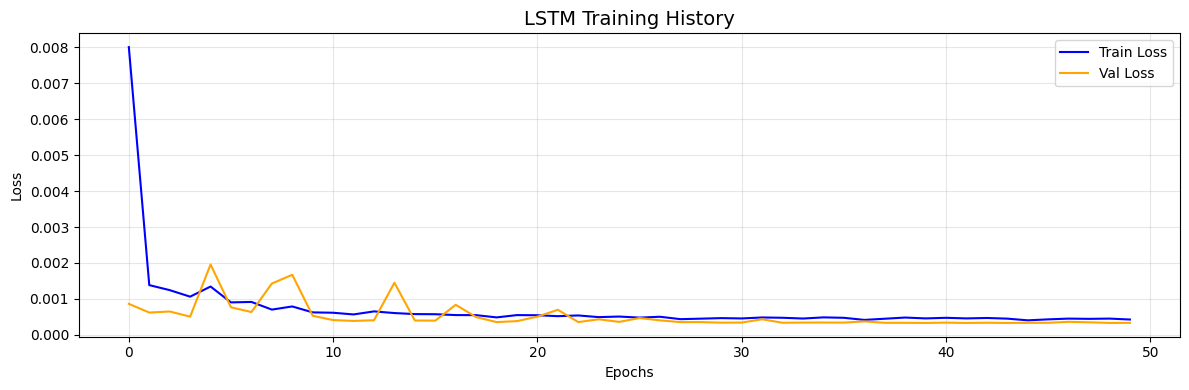

In [45]:
# Cell 16 — Training Loss Plot
plt.figure(figsize=(12, 4))
plt.plot(history_lstm.history['loss'],     label='Train Loss', color='blue')
plt.plot(history_lstm.history['val_loss'], label='Val Loss',   color='orange')
plt.title('LSTM Training History', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
# Cell 17 — Predictions + Metrics
y_pred_scaled = lstm_model.predict(X_test_l)
y_pred  = lstm_scaler.inverse_transform(y_pred_scaled).flatten()
y_actual= lstm_scaler.inverse_transform(y_test_l.reshape(-1,1)).flatten()

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae  = mean_absolute_error(y_actual, y_pred)
r2   = r2_score(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print("="*42)
print("   LSTM — FINAL RESULTS")
print("="*42)
print(f"   RMSE : ₹{rmse:.2f}  (avg error in rupees)")
print(f"   MAE  : ₹{mae:.2f}")
print(f"   R²   : {r2:.4f}  ← Main metric")
print(f"   MAPE : {mape:.2f}%")
print("="*42)

# ML vs LSTM Comparison
print("\n📊 Basic ML vs LSTM Comparison:")
print(f"   Logistic Regression Accuracy : 51.67%")
print(f"   Random Forest Accuracy       : 48.75%")
print(f"   Gradient Boosting Accuracy   : 49.16%")
print(f"   LSTM R²                      : {r2:.4f} ⭐")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
   LSTM — FINAL RESULTS
   RMSE : ₹27.00  (avg error in rupees)
   MAE  : ₹21.34
   R²   : 0.9682  ← Main metric
   MAPE : 1.63%

📊 Basic ML vs LSTM Comparison:
   Logistic Regression Accuracy : 51.67%
   Random Forest Accuracy       : 48.75%
   Gradient Boosting Accuracy   : 49.16%
   LSTM R²                      : 0.9682 ⭐


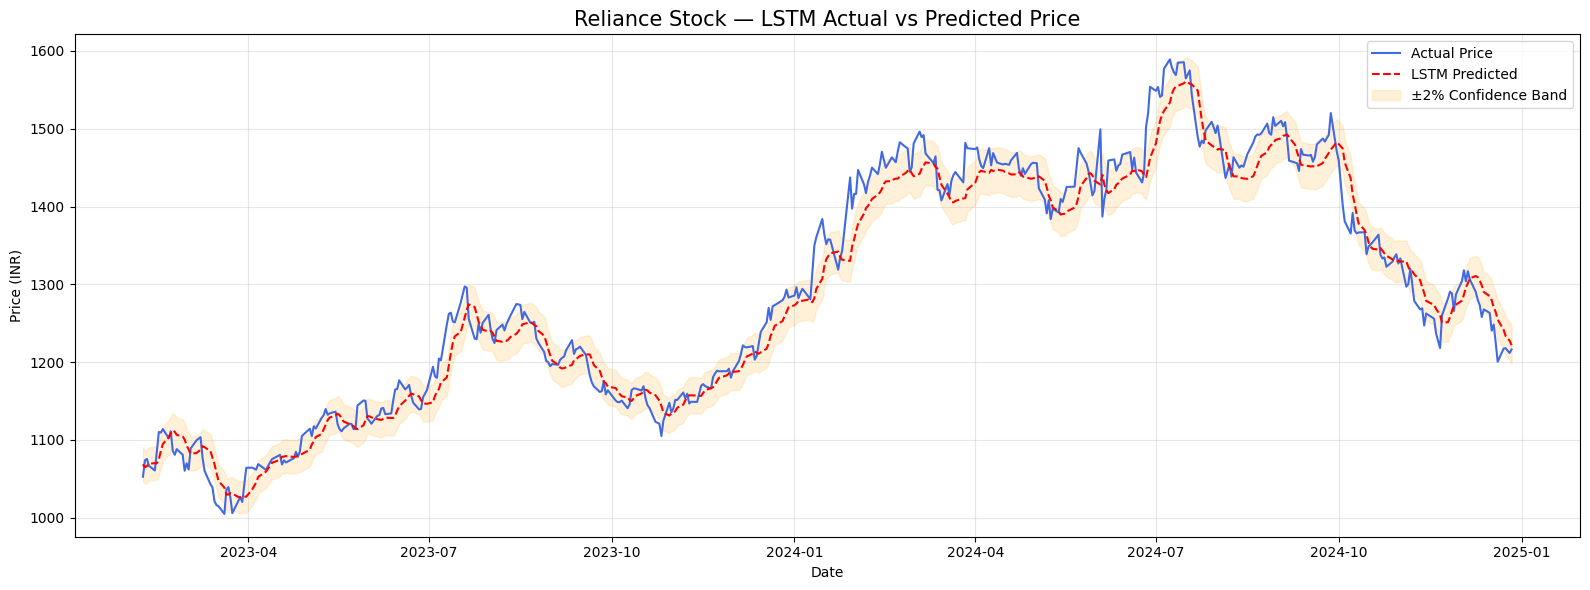

In [47]:
# Cell 18 — Actual vs Predicted Chart
test_dates = df['Date'].iloc[split_lstm + SEQ_LEN:].reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(test_dates, y_actual, label='Actual Price',
         color='royalblue', linewidth=1.5)
plt.plot(test_dates, y_pred,   label='LSTM Predicted',
         color='red', linewidth=1.5, linestyle='--')
plt.fill_between(test_dates,
                 y_pred * 0.98, y_pred * 1.02,
                 alpha=0.15, color='orange', label='±2% Confidence Band')
plt.title('Reliance Stock — LSTM Actual vs Predicted Price', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

⏳ Generating 30-day forecast...


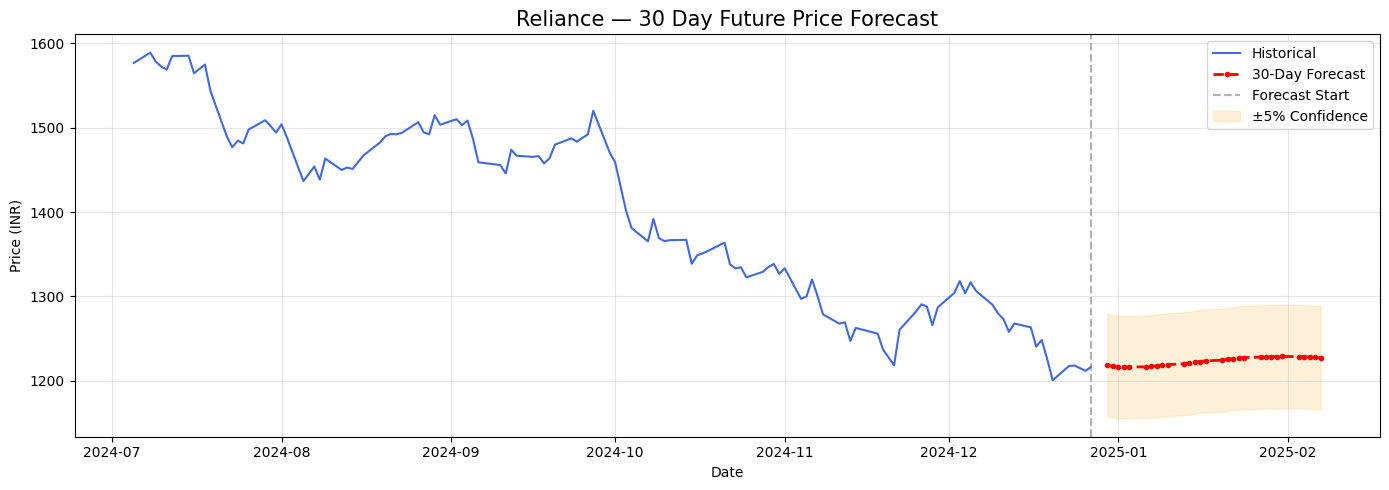


📈 30-Day Forecast Summary:
   Current Price  : ₹1216.19
   Predicted High : ₹1228.66
   Predicted Low  : ₹1215.97
   30-Day End     : ₹1227.32
   Expected Change: +0.92%
   Trend          : 📈 BULLISH


In [48]:
# Cell 19 — Future 30 Days Forecast
print("⏳ Generating 30-day forecast...")

last_seq = scaled[-SEQ_LEN:].reshape(1, SEQ_LEN, 1)
future_preds = []

for _ in range(30):
    pred = lstm_model.predict(last_seq, verbose=0)[0][0]
    future_preds.append(pred)
    last_seq = np.append(last_seq[:, 1:, :], [[[pred]]], axis=1)

future_prices = lstm_scaler.inverse_transform(
    np.array(future_preds).reshape(-1, 1)).flatten()

last_date    = df['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                              periods=30, freq='B')

plt.figure(figsize=(14, 5))
plt.plot(df['Date'].tail(120), df['Close'].tail(120),
         label='Historical', color='royalblue', linewidth=1.5)
plt.plot(future_dates, future_prices,
         label='30-Day Forecast', color='red',
         linewidth=2, linestyle='--', marker='o', markersize=3)
plt.axvline(x=last_date, color='grey', linestyle='--',
            alpha=0.6, label='Forecast Start')
plt.fill_between(future_dates,
                 future_prices * 0.95, future_prices * 1.05,
                 alpha=0.15, color='orange', label='±5% Confidence')
plt.title('Reliance — 30 Day Future Price Forecast', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

current = df['Close'].iloc[-1]
print(f"\n📈 30-Day Forecast Summary:")
print(f"   Current Price  : ₹{current:.2f}")
print(f"   Predicted High : ₹{max(future_prices):.2f}")
print(f"   Predicted Low  : ₹{min(future_prices):.2f}")
print(f"   30-Day End     : ₹{future_prices[-1]:.2f}")
change = ((future_prices[-1] - current) / current) * 100
trend  = "📈 BULLISH" if future_prices[-1] > current else "📉 BEARISH"
print(f"   Expected Change: {change:+.2f}%")
print(f"   Trend          : {trend}")

In [49]:
# Cell 20 — Save Model
lstm_model.save('reliance_lstm_model.h5')
print("✅ Model saved — reliance_lstm_model.h5")
print("\n🎉 StockPredict AI — Complete!")
print("   Basic ML  → Direction prediction (Classification)")
print("   LSTM      → Price prediction (Regression) ⭐")

✅ Model saved — reliance_lstm_model.h5

🎉 StockPredict AI — Complete!
   Basic ML  → Direction prediction (Classification)
   LSTM      → Price prediction (Regression) ⭐
